In [1]:
# CELL 1
# Driver AI - Entity Risk Model

#Notebook này dùng để:
#- huấn luyện mô hình Driver AI trên lõi mới `api/process_ai`
#- đọc metrics và artifact đã sinh ra
#- hiển thị các hình phục vụ báo cáo
#- thử dự đoán cho một driver mẫu

#Notebook này chỉ đóng vai trò:
#- điều phối
#- phân tích
#- trình bày kết quả

#Logic lõi nằm trong:
#- `api.process_ai.core`
#- `api.process_ai.entity`

In [2]:
# CELL 2
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from api.process_ai.entity.builders.driver import (
    default_driver_task_spec,
    build_driver_training_frame,
)
from api.process_ai.entity.trainers import train_driver_entity_model
from api.process_ai.entity.inference import predict_driver_risk, print_driver_prediction_report

# Đổi toàn bộ notebook sang nền sáng, chữ đen
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
plt.rcParams["text.color"] = "black"

In [3]:
# CELL 3
spec = default_driver_task_spec()
spec

TaskSpec(task_key='driver_ai', task_kind='entity', artifact_dir=WindowsPath('D:/logistics_AI/model/entity_models/driver'), label_column='target_next_3m_incident', model_candidates=['logreg', 'rf', 'hgb'], threshold_policy='fixed_0_45', validation_months=3, test_months=6, random_state=42, legacy_model_path=None, metadata={'entity_name': 'driver', 'builder_name': 'driver'})

In [4]:
# CELL 4
result = train_driver_entity_model(spec)

=== RUN TRAINING PIPELINE: driver_ai (entity) ===
=== FIT MODEL ===
=== MODEL BENCHMARK ON VALIDATION ===

--- TRAIN LOGREG ---
logreg | PR-AUC=0.15403918187988508 | ROC-AUC=0.5198585218480584 | Recall=0.34146341463414637 | Pred+Rate=0.34408602150537637

--- TRAIN RF ---
rf | PR-AUC=0.14501771235782862 | ROC-AUC=0.556996536732739 | Recall=0.04878048780487805 | Pred+Rate=0.021505376344086023

--- TRAIN HGB ---
hgb | PR-AUC=0.1160990642327849 | ROC-AUC=0.5273745486699579 | Recall=0.0 | Pred+Rate=0.005376344086021506

=== BEST MODEL ON VALIDATION ===
Best model: logreg
Best validation PR-AUC: 0.15403918187988508

=== THRESHOLD SWEEP ON VALIDATION ===
 threshold  accuracy  precision   recall       f1  predicted_positive_rate  tp  fp  tn  fn
      0.10  0.110215   0.110215 1.000000 0.198547                 1.000000  41 331   0   0
      0.15  0.112903   0.110512 1.000000 0.199029                 0.997312  41 330   1   0
      0.20  0.115591   0.110811 1.000000 0.199513                 0.994

In [5]:
# CELL 5
metrics = result.metrics

{
    "best_model_name": metrics.get("best_model_name"),
    "threshold": metrics.get("threshold"),
    "accuracy": metrics.get("accuracy"),
    "precision": metrics.get("precision"),
    "recall": metrics.get("recall"),
    "f1": metrics.get("f1"),
    "roc_auc": metrics.get("roc_auc"),
    "pr_auc": metrics.get("pr_auc"),
}

{'best_model_name': 'logreg',
 'threshold': 0.45,
 'accuracy': 0.5497311827956989,
 'precision': 0.1553672316384181,
 'recall': 0.6043956043956044,
 'f1': 0.24719101123595505,
 'roc_auc': 0.5872641906332565,
 'pr_auc': 0.17159572818800334}

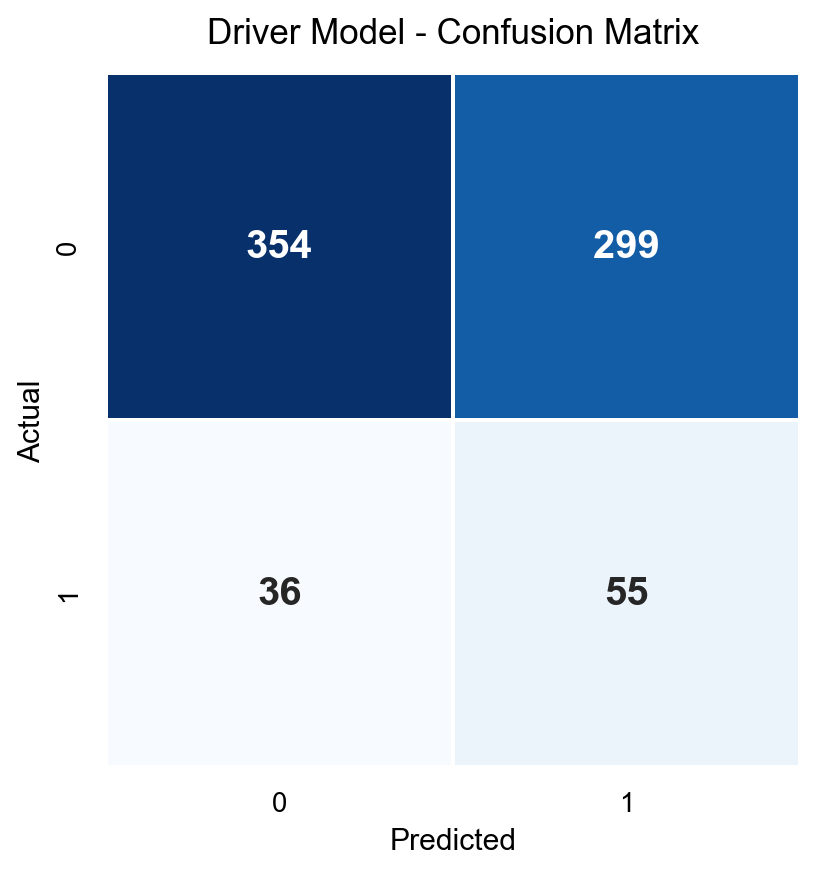

In [6]:
# CELL 6
conf_matrix_path = Path(result.artifact_paths["confusion_matrix_png"])
display(Image(filename=str(conf_matrix_path)))# CELL 7# CELL # CELL 7# CELL 7#CELL 7


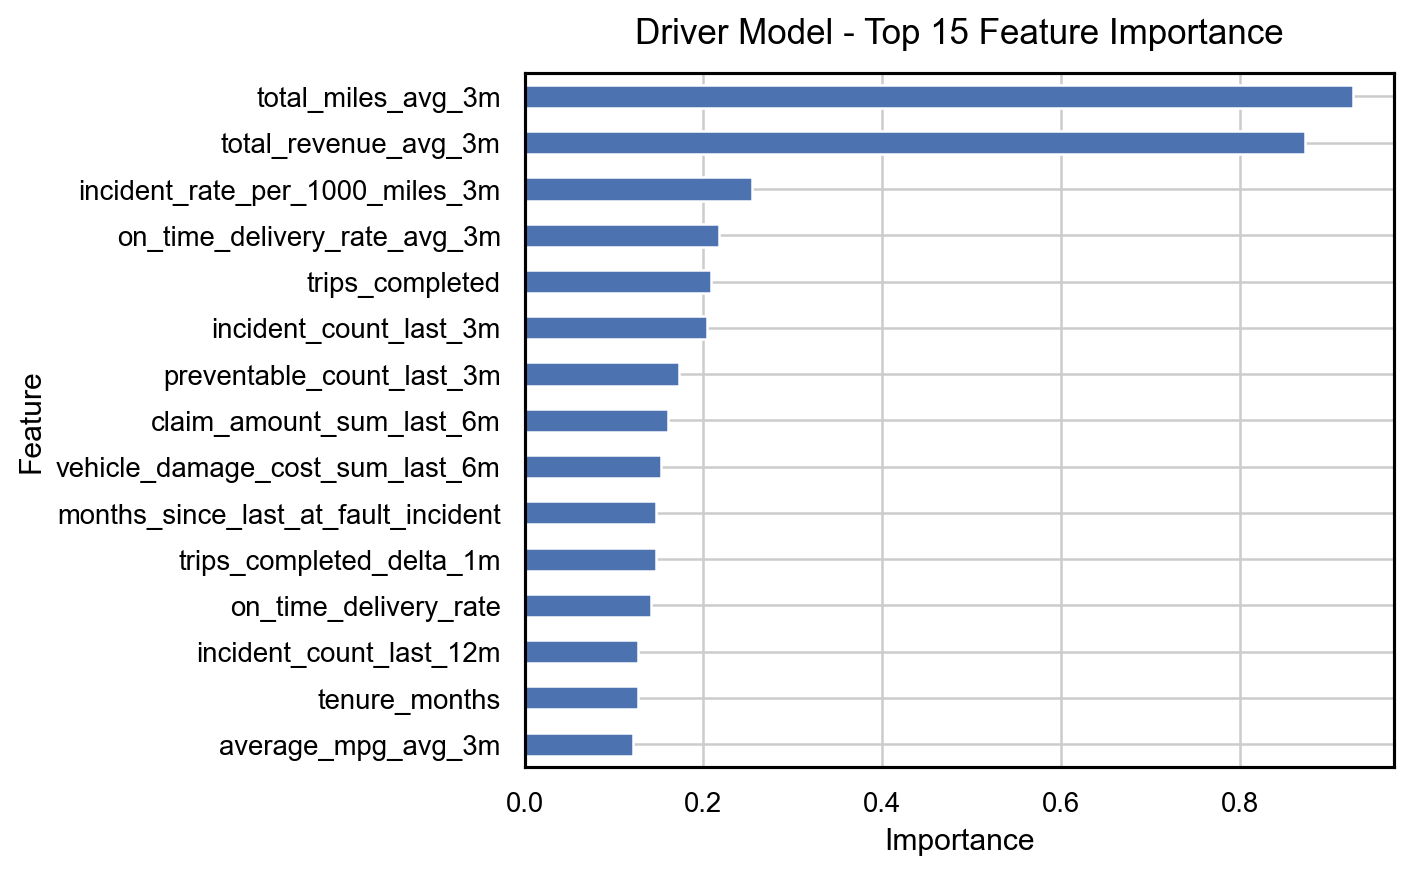

In [7]:
#CELL 7
feature_importance_path = Path(result.artifact_paths["feature_importance_png"])
display(Image(filename=str(feature_importance_path)))

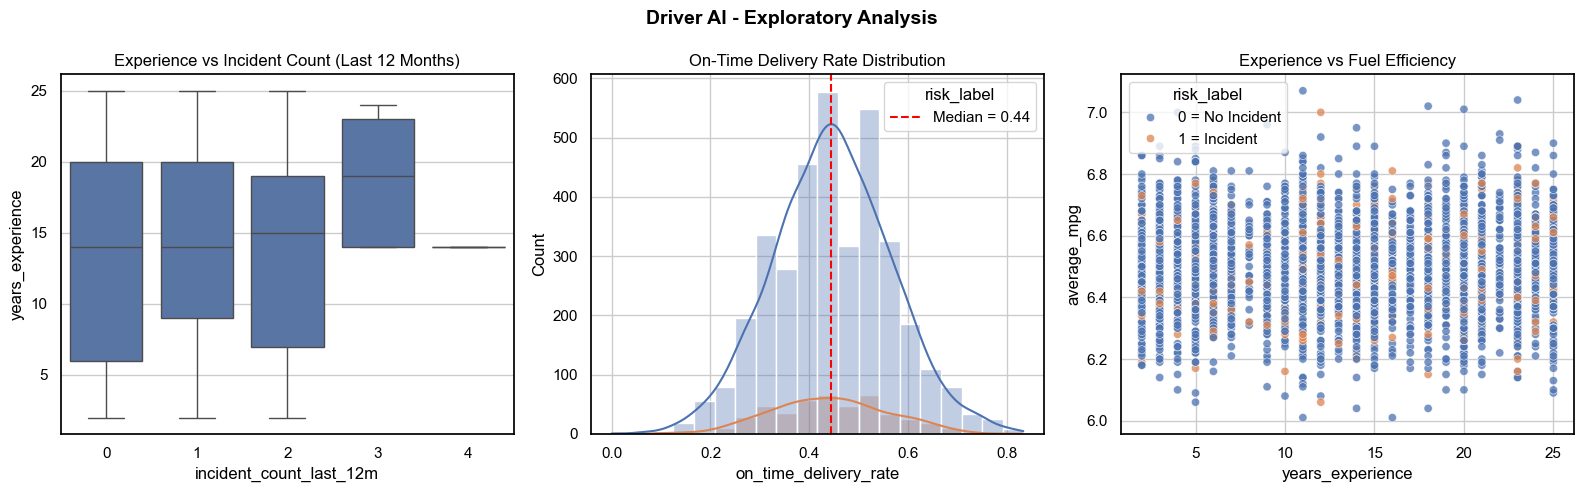

Đã lưu hình tại: D:\logistics_AI\model\entity_models\driver\driver_eda_panel.png


In [8]:
# CELL 8
driver_df = build_driver_training_frame()
save_path = Path(spec.artifact_dir) / "driver_eda_panel.png"

df_plot = driver_df.copy()
target_col = "target_next_3m_incident"

df_plot["risk_label"] = df_plot[target_col].map({
    0: "0 = No Incident",
    1: "1 = Incident",
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Driver AI - Exploratory Analysis", fontsize=14, fontweight="bold")

# Panel 1
box_df = df_plot.copy()
box_df["incident_count_last_12m_cat"] = box_df["incident_count_last_12m"].astype(int).astype(str)

sns.boxplot(
    data=box_df,
    x="incident_count_last_12m_cat",
    y="years_experience",
    ax=axes[0]
)
axes[0].set_title("Experience vs Incident Count (Last 12 Months)")
axes[0].set_xlabel("incident_count_last_12m")
axes[0].set_ylabel("years_experience")

# Panel 2
sns.histplot(
    data=df_plot,
    x="on_time_delivery_rate",
    hue="risk_label",
    bins=20,
    kde=True,
    stat="count",
    alpha=0.35,
    ax=axes[1]
)

ref_line = df_plot["on_time_delivery_rate"].median()
axes[1].axvline(
    ref_line,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Median = {ref_line:.2f}"
)

axes[1].set_title("On-Time Delivery Rate Distribution")
axes[1].set_xlabel("on_time_delivery_rate")
axes[1].set_ylabel("Count")

handles, labels = axes[1].get_legend_handles_labels()
if handles:
    axes[1].legend(handles=handles, labels=labels, title="risk_label")

# Panel 3
sns.scatterplot(
    data=df_plot,
    x="years_experience",
    y="average_mpg",
    hue="risk_label",
    alpha=0.75,
    ax=axes[2]
)
axes[2].set_title("Experience vs Fuel Efficiency")
axes[2].set_xlabel("years_experience")
axes[2].set_ylabel("average_mpg")

plt.tight_layout()
plt.savefig(save_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Đã lưu hình tại: {save_path}")

In [9]:
# CELL 10
artifact_summary = pd.DataFrame([
    {
        "artifact_name": "EDA panel",
        "file_path": str(Path(spec.artifact_dir) / "driver_eda_panel.png"),
        "use_for_report": "Hình phân tích dữ liệu đầu vào",
    },
    {
        "artifact_name": "Confusion matrix",
        "file_path": str(Path(spec.artifact_dir) / "confusion_matrix.png"),
        "use_for_report": "Hình đánh giá dự đoán",
    },
    {
        "artifact_name": "Feature importance",
        "file_path": str(Path(spec.artifact_dir) / "feature_importance.png"),
        "use_for_report": "Hình giải thích biến quan trọng",
    },
    {
        "artifact_name": "Metrics JSON",
        "file_path": str(Path(spec.artifact_dir) / "metrics.json"),
        "use_for_report": "Nguồn số liệu metric chính",
    },
    {
        "artifact_name": "Threshold sweep CSV",
        "file_path": str(Path(spec.artifact_dir) / "threshold_sweep.csv"),
        "use_for_report": "Phân tích threshold",
    },
])

final_metric_summary = pd.DataFrame([
    {
        "best_model_name": metrics.get("best_model_name"),
        "threshold": metrics.get("threshold"),
        "accuracy": metrics.get("accuracy"),
        "precision": metrics.get("precision"),
        "recall": metrics.get("recall"),
        "f1": metrics.get("f1"),
        "roc_auc": metrics.get("roc_auc"),
        "pr_auc": metrics.get("pr_auc"),
    }
])

print("=== FINAL METRIC SUMMARY ===")
display(final_metric_summary)

print("=== REPORT ARTIFACT SUMMARY ===")
display(artifact_summary)

=== FINAL METRIC SUMMARY ===


,best_model_name,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,logreg,0.45,0.549731,0.155367,0.604396,0.247191,0.587264,0.171596


=== REPORT ARTIFACT SUMMARY ===


,artifact_name,file_path,use_for_report
0,EDA panel,D:\logistics_AI\model\entity_models\driver\dri...,Hình phân tích dữ liệu đầu vào
1,Confusion matrix,D:\logistics_AI\model\entity_models\driver\con...,Hình đánh giá dự đoán
2,Feature importance,D:\logistics_AI\model\entity_models\driver\fea...,Hình giải thích biến quan trọng
3,Metrics JSON,D:\logistics_AI\model\entity_models\driver\met...,Nguồn số liệu metric chính
4,Threshold sweep CSV,D:\logistics_AI\model\entity_models\driver\thr...,Phân tích threshold
